In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.getenv("DB_URL"))

pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")
print("Connected:", engine.connect().closed is False)

Connected: True


In [3]:
query = """
SELECT
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp AS purchased_at,
    CAST(SUM(oi.price + oi.freight_value) AS double precision) AS revenue
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-01-01'
  AND o.order_purchase_timestamp <  '2018-09-01'
GROUP BY c.customer_unique_id, o.order_id, o.order_purchase_timestamp
"""
df = pd.read_sql(query, engine, parse_dates=["purchased_at"])
df.head()

,customer_unique_id,order_id,purchased_at,revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,27.19
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,43.62
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,196.89


In [4]:
print("rows (orders):        ", len(df))
print("unique orders:        ", df["order_id"].nunique())
print("unique customers:     ", df["customer_unique_id"].nunique())
print("total revenue:        ", round(df["revenue"].sum(), 0))
print("first / last order:   ", df["purchased_at"].min(), "/", df["purchased_at"].max())

n = df.groupby("customer_unique_id").size()
print("1 order / 2 orders / 3+:", (n == 1).sum(), (n == 2).sum(), (n >= 3).sum())

rows (orders):         96211
unique orders:         96211
unique customers:      93104
total revenue:         15373120.0
first / last order:    2017-01-05 11:56:06 / 2018-08-29 15:00:37
1 order / 2 orders / 3+: 90315 2562 227


## Data validation
Loaded delivered orders (Jan 2017 - Aug 2018) from PostgreSQL and
confirmed the totals match the SQL analysis: 96,211 orders, 93,104
unique customers, R$15,373,120 total revenue.

In [5]:
snapshot_date = df["purchased_at"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg(
    last_purchase=("purchased_at", "max"),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days

# Recency and Monetary: quantile scores, 5 = best (recent / high spend)
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Frequency: custom rule, not quantiles (97% of customers = 1 order)
rfm["f_score"] = np.where(rfm["frequency"] == 1, 1,
                   np.where(rfm["frequency"] == 2, 3, 5))

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,r_score,m_score,f_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112,4,4,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115,4,1,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537,1,2,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288,2,4,1


In [6]:
print(rfm[["recency", "frequency", "monetary"]].describe())
print()
print("f_score counts:\n", rfm["f_score"].value_counts().sort_index())

        recency  frequency  monetary
count 93,104.00  93,104.00 93,104.00
mean     236.70       1.03    165.12
std      150.94       0.21    226.36
min        1.00       1.00      9.59
25%      114.00       1.00     63.01
50%      218.00       1.00    107.78
75%      345.00       1.00    182.43
max      602.00      15.00 13,664.08

f_score counts:
 f_score
1    90315
3     2562
5      227
Name: count, dtype: int64


## RFM Segments

Combine the R, F, and M scores into named segments. Because 97% of
customers have exactly one order, most rules are Recency/Monetary-driven
within the "1 order" group, with a separate track for repeat customers.

In [7]:
def segment(row):
    if row["f_score"] >= 5:
        return "Loyal (3+ orders)"
    if row["f_score"] == 3:
        return "Repeat (2 orders)"
    # Everyone below this point ordered exactly once (f_score == 1)
    if row["r_score"] >= 4 and row["m_score"] >= 4:
        return "Big first order, recent"
    if row["r_score"] >= 4:
        return "Recent one-time buyer"
    if row["m_score"] >= 4:
        return "Big first order, lapsed"
    if row["r_score"] <= 2:
        return "Lapsed one-time buyer"
    return "One-time buyer"

rfm["segment"] = rfm.apply(segment, axis=1)

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_unique_id", "count"),
    total_revenue=("monetary", "sum"),
    avg_recency=("recency", "mean"),
    avg_orders=("frequency", "mean")
).reset_index()

segment_summary["pct_customers"] = (100 * segment_summary["customers"] / len(rfm)).round(1)
segment_summary["pct_revenue"] = (100 * segment_summary["total_revenue"] / rfm["monetary"].sum()).round(1)
segment_summary = segment_summary.sort_values("total_revenue", ascending=False)
segment_summary

,segment,customers,total_revenue,avg_recency,avg_orders,pct_customers,pct_revenue
0,"Big first order, lapsed",20552,"6,129,799.03",334.21,1.00,22.10,39.90
1,"Big first order, recent",14463,"4,366,811.55",91.61,1.00,15.50,28.40
2,Lapsed one-time buyer,22345,"1,624,173.57",394.15,1.00,24.00,10.60
5,Recent one-time buyer,21765,"1,586,514.63",89.97,1.00,23.40,10.30
4,One-time buyer,11190,"805,288.04",220.41,1.00,12.00,5.20
6,Repeat (2 orders),2562,"745,294.46",221.08,2.00,2.80,4.80
3,Loyal (3+ orders),227,"115,238.73",202.89,3.40,0.20,0.70


**Key finding:** "Big first order" customers (one large purchase, whether
recent or lapsed) make up 37.6% of customers but 68.3% of revenue. True
repeat/loyal customers are only 3.0% of customers and 5.5% of revenue.
This confirms the SQL finding that revenue growth depends on acquiring
new customers who place a large first order, not on repeat purchasing.

**Actionable segment:** "Big first order, lapsed" (20,552 customers,
39.9% of revenue, average 334 days since last order) is the largest
revenue segment and the best win-back target.

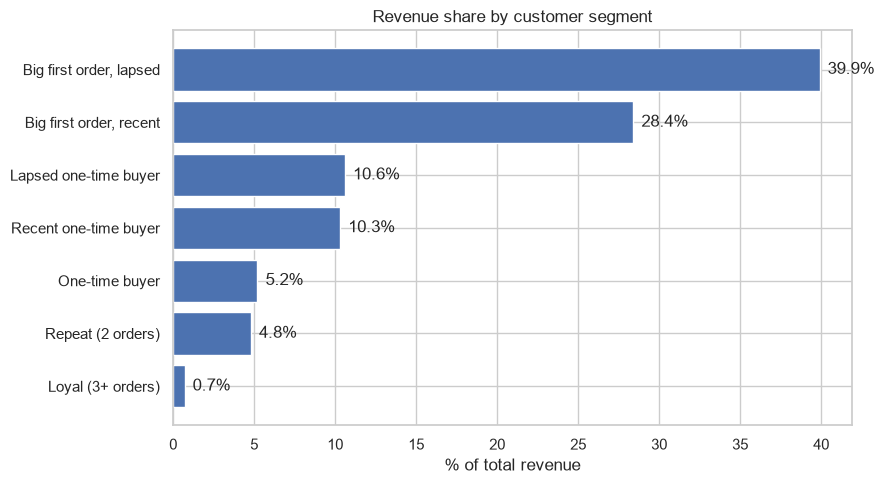

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
order = segment_summary.sort_values("pct_revenue", ascending=True)
ax.barh(order["segment"], order["pct_revenue"], color="#4C72B0")
ax.set_xlabel("% of total revenue")
ax.set_title("Revenue share by customer segment")
for i, v in enumerate(order["pct_revenue"]):
    ax.text(v + 0.5, i, f"{v}%", va="center")
plt.tight_layout()
plt.savefig("../dashboard/rfm_segments.png", dpi=150)
plt.show()

## Cohort Retention

For each customer, find their first-purchase month (the cohort). Then
for every following month, calculate what share of that cohort placed
another order. This tests whether growth depends on repeat purchases
from existing cohorts or on constantly acquiring new customers.

In [9]:
# Assign each customer to a cohort = month of their first order
df["order_month"] = df["purchased_at"].dt.to_period("M")
cohort_month = df.groupby("customer_unique_id")["order_month"].min().rename("cohort")
df = df.merge(cohort_month, on="customer_unique_id")

# Months since first purchase (0 = the cohort month itself)
df["period_number"] = (df["order_month"] - df["cohort"]).apply(lambda x: x.n)

# Count distinct customers active in each cohort/period combination
cohort_counts = df.groupby(["cohort", "period_number"])["customer_unique_id"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort", columns="period_number", values="customer_unique_id")

# Retention % = active customers / cohort size (the period 0 count)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Keep only periods 0-6 for readability; later cohorts won't have late periods anyway
retention = retention.iloc[:, :7]
retention

period_number,0,1,2,3,4,5,6
cohort,,,,,,,
2017-01,100.00,0.30,0.30,0.10,0.40,0.10,0.40
2017-02,100.00,0.20,0.30,0.10,0.40,0.10,0.20
2017-03,100.00,0.40,0.40,0.40,0.40,0.20,0.20
2017-04,100.00,0.60,0.20,0.20,0.30,0.30,0.40
2017-05,100.00,0.50,0.50,0.30,0.30,0.30,0.40
2017-06,100.00,0.50,0.40,0.40,0.30,0.40,0.40
2017-07,100.00,0.50,0.30,0.20,0.30,0.20,0.30
2017-08,100.00,0.70,0.30,0.30,0.30,0.50,0.30
2017-09,100.00,0.70,0.50,0.30,0.40,0.20,0.20


**Key finding:** Retention is under 1% in every period, for every cohort,
with no exceptions. This isn't limited to a few weak cohorts; it's a
structural pattern across the entire customer base. Combined with the RFM
result, growth in this business comes almost entirely from acquiring new
customers who place one large order, not from any cohort returning.

**Limitation:** with cohort sizes and retention this low, month-to-month
differences (e.g. 0.7% vs 0.1%) reflect only a handful of customers and
should not be read as meaningful variation between cohorts.

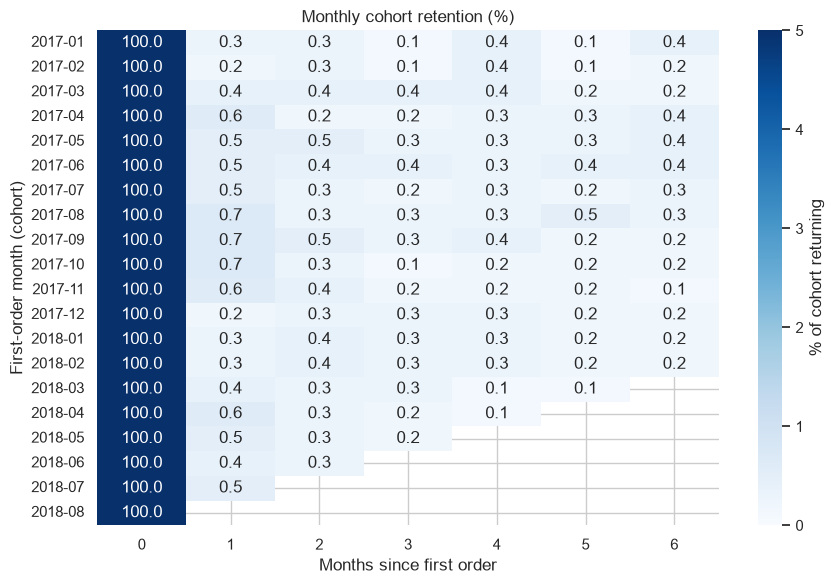

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(retention, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=5,
            cbar_kws={"label": "% of cohort returning"}, ax=ax)
ax.set_title("Monthly cohort retention (%)")
ax.set_xlabel("Months since first order")
ax.set_ylabel("First-order month (cohort)")
plt.tight_layout()
plt.savefig("../dashboard/cohort_retention.png", dpi=150)
plt.show()

In [11]:
segment_summary.to_csv("../dashboard/rfm_segments.csv", index=False)
rfm[["customer_unique_id", "segment", "recency", "frequency", "monetary"]].to_csv(
    "../dashboard/rfm_customer_detail.csv", index=False
)
print("Saved.")

Saved.
